# Audio Module: Spoken Colour Command Classifier

This notebook records spoken commands from multiple speakers, trains an ML audio classifier, and converts predictions into a target state/color setpoint for the main execution loop.

Command set:

- `go red`
- `go blue`
- `go green`
- `go yellow`
- `hold`
- `stop`


## 1. Setup

Run this cell once in a fresh notebook environment. `sounddevice` needs microphone access on the local machine.


In [2]:
%pip install --user -q tensorflow sounddevice soundfile


Note: you may need to restart the kernel to use updated packages.


In [344]:
import json
import math
import pathlib
import random
import shutil
import time
from datetime import datetime

import numpy as np
import sounddevice as sd
import soundfile as sf
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Project Configuration

The folder labels use underscores because `audio_dataset_from_directory` treats folder names as class labels. The prompts and exported metadata keep the human spoken phrases.


In [631]:
PROJECT_ROOT = pathlib.Path.cwd()

COMMANDS = [
    "go_red",
    "go_blue",
    "go_green",
    "go_yellow",
    "hold",
    "stop",
]

COMMAND_PHRASES = {
    "go_red": "go red",
    "go_blue": "go blue",
    "go_green": "go green",
    "go_yellow": "go yellow",
    "hold": "hold",
    "stop": "stop",
}

SAMPLE_RATE = 16_000
CLIP_SECONDS = 1.25
OUTPUT_SEQUENCE_LENGTH = int(SAMPLE_RATE * CLIP_SECONDS)

BATCH_SIZE = 32
SEED = 42
MIN_CONFIDENCE = 0.30
STOP_CONFIDENCE = 0.55

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Commands:", [COMMAND_PHRASES[c] for c in COMMANDS])
print("Samples per clip:", OUTPUT_SEQUENCE_LENGTH)


Commands: ['go red', 'go blue', 'go green', 'go yellow', 'hold', 'stop']
Samples per clip: 20000


In [632]:
from scipy.signal import resample_poly

def resample_speaker_to_16khz(speaker_id):
    speaker_dir = RAW_DIR / speaker_id

    for wav_path in speaker_dir.rglob("*.wav"):
        audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)

        if sr == SAMPLE_RATE:
            continue

        print(f"Resampling {wav_path.name}: {sr} -> {SAMPLE_RATE}")

        # Convert to mono
        audio = np.mean(audio, axis=1)

        if sr == 48000 and SAMPLE_RATE == 16000:
            audio_resampled = resample_poly(audio, up=1, down=3)
        else:
            new_length = int(len(audio) * SAMPLE_RATE / sr)
            audio_resampled = scipy.signal.resample(audio, new_length)

        sf.write(wav_path, audio_resampled.astype(np.float32), SAMPLE_RATE)

    print("Done resampling:", speaker_id)

In [633]:
resample_speaker_to_16khz("speaker04")

Done resampling: speaker04


In [634]:
import scipy.signal
from scipy.signal import resample_poly

def resample_speaker_to_16khz(speaker_id):
    speaker_dir = RAW_DIR / speaker_id

    for wav_path in speaker_dir.rglob("*.wav"):
        audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)

        if sr == SAMPLE_RATE:
            continue

        print(f"Resampling {wav_path.name}: {sr} -> {SAMPLE_RATE}")

        audio = np.mean(audio, axis=1)

        if sr == 48000 and SAMPLE_RATE == 16000:
            audio_resampled = resample_poly(audio, up=1, down=3)
        else:
            new_length = int(len(audio) * SAMPLE_RATE / sr)
            audio_resampled = scipy.signal.resample(audio, new_length)

        sf.write(wav_path, audio_resampled.astype(np.float32), SAMPLE_RATE)

    print("Done resampling:", speaker_id)

In [635]:
resample_speaker_to_16khz("speaker03")

Done resampling: speaker03


In [870]:
import scipy.signal
from scipy.signal import resample_poly

def resample_speaker_to_16khz(speaker_id):
    speaker_dir = RAW_DIR / speaker_id

    for wav_path in speaker_dir.rglob("*.wav"):
        audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)

        if sr == SAMPLE_RATE:
            continue

        print(f"Resampling {wav_path.name}: {sr} -> {SAMPLE_RATE}")

        audio = np.mean(audio, axis=1)

        if sr == 48000 and SAMPLE_RATE == 16000:
            audio_resampled = resample_poly(audio, up=1, down=3)
        else:
            new_length = int(len(audio) * SAMPLE_RATE / sr)
            audio_resampled = scipy.signal.resample(audio, new_length)

        sf.write(wav_path, audio_resampled.astype(np.float32), SAMPLE_RATE)

    print("Done resampling:", speaker_id)

In [871]:
resample_speaker_to_16khz("speaker05")

Resampling H1.wav: 48000 -> 16000
Resampling H10.wav: 48000 -> 16000
Resampling H11.wav: 48000 -> 16000
Resampling H12.wav: 48000 -> 16000
Resampling H13.wav: 48000 -> 16000
Resampling H14.wav: 48000 -> 16000
Resampling H15.wav: 48000 -> 16000
Resampling H16.wav: 48000 -> 16000
Resampling H18.wav: 48000 -> 16000
Resampling H19.wav: 48000 -> 16000
Resampling H2.wav: 48000 -> 16000
Resampling H20.wav: 48000 -> 16000
Resampling H3.wav: 48000 -> 16000
Resampling H4.wav: 48000 -> 16000
Resampling H5.wav: 48000 -> 16000
Resampling H6.wav: 48000 -> 16000
Resampling H7.wav: 48000 -> 16000
Resampling H8.wav: 48000 -> 16000
Resampling H9.wav: 48000 -> 16000
Resampling S1.wav: 48000 -> 16000
Resampling S10.wav: 48000 -> 16000
Resampling S11.wav: 48000 -> 16000
Resampling S12.wav: 48000 -> 16000
Resampling S13.wav: 48000 -> 16000
Resampling S14.wav: 48000 -> 16000
Resampling S15.wav: 48000 -> 16000
Resampling S16.wav: 48000 -> 16000
Resampling S17.wav: 48000 -> 16000
Resampling S18.wav: 48000 -> 1

## 3. Data and Model Folders

Raw recordings are stored by speaker and command. Clean fixed-length clips are promoted into class folders for training.


In [872]:
DATA_ROOT = PROJECT_ROOT / "data"

BRONZE_AUDIO = DATA_ROOT / "bronze" / "audio"
SILVER_AUDIO = DATA_ROOT / "silver" / "audio"
GOLD_AUDIO = DATA_ROOT / "gold" / "audio"

RAW_DIR = BRONZE_AUDIO / "raw"
SILVER_CLIPS_DIR = SILVER_AUDIO / "clips"
GOLD_SPLIT_DIR = GOLD_AUDIO / "commands"

MODEL_ROOT = PROJECT_ROOT / "models" / "audio_command_classifier"
LATEST_STATE_PATH = PROJECT_ROOT / "latest_audio_target_state.json"

for path in [RAW_DIR, SILVER_CLIPS_DIR, GOLD_SPLIT_DIR, MODEL_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

for command in COMMANDS:
    (SILVER_CLIPS_DIR / command).mkdir(parents=True, exist_ok=True)
    for split in ["train", "val", "test"]:
        (GOLD_SPLIT_DIR / split / command).mkdir(parents=True, exist_ok=True)

print("Bronze raw audio:", RAW_DIR)
print("Silver clips:", SILVER_CLIPS_DIR)
print("Gold dataset:", GOLD_SPLIT_DIR)
print("Model output:", MODEL_ROOT)


Bronze raw audio: C:\Users\aritr\Downloads\data\bronze\audio\raw
Silver clips: C:\Users\aritr\Downloads\data\silver\audio\clips
Gold dataset: C:\Users\aritr\Downloads\data\gold\audio\commands
Model output: C:\Users\aritr\Downloads\models\audio_command_classifier


## 4. Target State / Color Setpoint Mapping

The classifier emits a command. `command_to_target_state` later turns that command into the state object sent to the main execution loop.


In [873]:
ACTION_MAP = {
    "go_red": {
        "mode": "colour_select",
        "target_colour": "red",
        "colour_setpoint": "red",
        "hold": False,
        "emergency_stop": False,
    },
    "go_blue": {
        "mode": "colour_select",
        "target_colour": "blue",
        "colour_setpoint": "blue",
        "hold": False,
        "emergency_stop": False,
    },
    "go_green": {
        "mode": "colour_select",
        "target_colour": "green",
        "colour_setpoint": "green",
        "hold": False,
        "emergency_stop": False,
    },
    "go_yellow": {
        "mode": "colour_select",
        "target_colour": "yellow",
        "colour_setpoint": "yellow",
        "hold": False,
        "emergency_stop": False,
    },
    "hold": {
        "mode": "hold",
        "target_colour": None,
        "colour_setpoint": None,
        "hold": True,
        "emergency_stop": False,
    },
    "stop": {
        "mode": "stop",
        "target_colour": None,
        "colour_setpoint": None,
        "hold": True,
        "emergency_stop": True,
    },
}

print(json.dumps(ACTION_MAP, indent=2))


{
  "go_red": {
    "mode": "colour_select",
    "target_colour": "red",
    "colour_setpoint": "red",
    "hold": false,
    "emergency_stop": false
  },
  "go_blue": {
    "mode": "colour_select",
    "target_colour": "blue",
    "colour_setpoint": "blue",
    "hold": false,
    "emergency_stop": false
  },
  "go_green": {
    "mode": "colour_select",
    "target_colour": "green",
    "colour_setpoint": "green",
    "hold": false,
    "emergency_stop": false
  },
  "go_yellow": {
    "mode": "colour_select",
    "target_colour": "yellow",
    "colour_setpoint": "yellow",
    "hold": false,
    "emergency_stop": false
  },
  "hold": {
    "mode": "hold",
    "target_colour": null,
    "colour_setpoint": null,
    "hold": true,
    "emergency_stop": false
  },
  "stop": {
    "mode": "stop",
    "target_colour": null,
    "colour_setpoint": null,
    "hold": true,
    "emergency_stop": true
  }
}


## 5. Record Spoken Commands from Multiple Speakers

Run the recording session once for each speaker with a different `speaker_id`, for example `speaker01`, `speaker02`, and `speaker03`. Aim for at least 20 clips per command per speaker.


In [640]:
def clean_speaker_id(speaker_id):
    speaker_id = str(speaker_id).strip().replace(" ", "_").lower()
    keep = []
    for ch in speaker_id:
        keep.append(ch if ch.isalnum() or ch in {"_", "-"} else "_")
    speaker_id = "".join(keep).strip("_")
    if not speaker_id:
        raise ValueError("speaker_id cannot be empty")
    return speaker_id


def make_speaker_dirs(speaker_id):
    speaker_id = clean_speaker_id(speaker_id)
    for command in COMMANDS:
        (RAW_DIR / speaker_id / command).mkdir(parents=True, exist_ok=True)
    return speaker_id


def record_one_sample(command, speaker_id, sample_number=None, clip_seconds=CLIP_SECONDS):
    if command not in COMMANDS:
        raise ValueError(f"Unknown command: {command}")

    speaker_id = make_speaker_dirs(speaker_id)
    phrase = COMMAND_PHRASES[command]
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    sample_tag = f"{sample_number:03d}" if sample_number is not None else timestamp
    file_name = f"{speaker_id}__{command}__{sample_tag}.wav"
    file_path = RAW_DIR / speaker_id / command / file_name

    input(f"Press Enter, then clearly say: '{phrase}'")
    print(f"Recording {clip_seconds:.1f}s for {speaker_id} / {phrase}...")
    audio = sd.rec(
        int(clip_seconds * SAMPLE_RATE),
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype="float32",
    )
    sd.wait()
    sf.write(file_path, audio, SAMPLE_RATE)
    print("Saved:", file_path)
    return file_path


def record_speaker_session(speaker_id, samples_per_command=20, commands=COMMANDS):
    speaker_id = make_speaker_dirs(speaker_id)
    print(f"Recording speaker: {speaker_id}")
    print(f"Samples per command: {samples_per_command}")
    for command in commands:
        print("\n" + "=" * 60)
        print("Now recording:", COMMAND_PHRASES[command])
        print("=" * 60)
        for i in range(1, samples_per_command + 1):
            record_one_sample(command, speaker_id, i)


In [641]:
# You already recorded speakers 1, 2, and 3.
# Keep this commented unless you want to record another speaker.
speaker_id = "speaker04"
samples_per_command = 20

record_speaker_session(speaker_id, samples_per_command)

Recording speaker: speaker04
Samples per command: 20

Now recording: go red


KeyboardInterrupt: Interrupted by user

## 6. Inspect Raw Recording Counts


In [874]:
def count_bronze_by_speaker():
    rows = []
    for speaker_dir in sorted(RAW_DIR.glob("*")):
        if not speaker_dir.is_dir():
            continue
        row = {"speaker": speaker_dir.name}
        for command in COMMANDS:
            row[command] = len(list((speaker_dir / command).glob("*.wav")))
        row["total"] = sum(row[c] for c in COMMANDS)
        rows.append(row)
    return rows


bronze_rows = count_bronze_by_speaker()
if not bronze_rows:
    print("No raw recordings yet. Record at least 3 speakers if possible.")
else:
    for row in bronze_rows:
        print(row)


{'speaker': 'speaker02', 'go_red': 20, 'go_blue': 20, 'go_green': 20, 'go_yellow': 20, 'hold': 20, 'stop': 20, 'total': 120}
{'speaker': 'speaker03', 'go_red': 20, 'go_blue': 20, 'go_green': 20, 'go_yellow': 20, 'hold': 20, 'stop': 20, 'total': 120}
{'speaker': 'speaker04', 'go_red': 20, 'go_blue': 20, 'go_green': 20, 'go_yellow': 20, 'hold': 20, 'stop': 20, 'total': 120}
{'speaker': 'speaker05', 'go_red': 20, 'go_blue': 20, 'go_green': 20, 'go_yellow': 20, 'hold': 19, 'stop': 20, 'total': 119}


## 7. Promote Raw Clips to Fixed-Length Training Clips

This step converts audio to mono, trims or pads every clip to two seconds, and peak-normalizes volume.


In [875]:
def align_speech_to_fixed_length(audio, target_samples=OUTPUT_SEQUENCE_LENGTH):
    audio = np.asarray(audio, dtype=np.float32)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    peak = np.max(np.abs(audio))
    rms = np.sqrt(np.mean(audio ** 2))

    if peak < 0.03 or rms < 0.003:
        return None, {"reason": "too_quiet", "peak": float(peak), "rms": float(rms)}

    threshold = max(0.015, peak * 0.08)
    active = np.where(np.abs(audio) > threshold)[0]

    if len(active) == 0:
        return None, {"reason": "no_speech_detected"}

    start = active[0]
    end = active[-1]

    pre_roll = int(0.08 * SAMPLE_RATE)
    post_roll = int(0.12 * SAMPLE_RATE)

    start = max(0, start - pre_roll)
    end = min(len(audio), end + post_roll)

    audio = audio[start:end]

    if len(audio) > target_samples:
        audio = audio[:target_samples]

    if len(audio) < target_samples:
        audio = np.pad(audio, (0, target_samples - len(audio)))

    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak * 0.95

    return audio.astype(np.float32), {"reason": "ok"}


def load_wav_as_fixed_length(path, target_samples=OUTPUT_SEQUENCE_LENGTH):
    audio, sr = sf.read(path, dtype="float32", always_2d=True)

    if sr != SAMPLE_RATE:
        raise ValueError(f"{path} has sample rate {sr}; expected {SAMPLE_RATE}")

    audio, info = align_speech_to_fixed_length(audio, target_samples=target_samples)

    if audio is None:
        raise ValueError(f"Skipping bad clip {path.name}: {info}")

    return audio


def promote_bronze_to_silver(overwrite=True):
    copied = 0
    skipped = 0
    bad = []

    if overwrite and SILVER_CLIPS_DIR.exists():
        shutil.rmtree(SILVER_CLIPS_DIR)

    for command in COMMANDS:
        (SILVER_CLIPS_DIR / command).mkdir(parents=True, exist_ok=True)

    for speaker_dir in sorted(RAW_DIR.glob("*")):
        if not speaker_dir.is_dir():
            continue

        speaker_id = speaker_dir.name
        for command in COMMANDS:
            for src in sorted((speaker_dir / command).glob("*.wav")):
                dst = SILVER_CLIPS_DIR / command / f"{speaker_id}__{command}__{src.stem}.wav"
                if dst.exists() and not overwrite:
                    skipped += 1
                    continue

                try:
                    audio = load_wav_as_fixed_length(src)
                except ValueError as exc:
                    bad.append(str(exc))
                    continue

                sf.write(dst, audio, SAMPLE_RATE)
                copied += 1

    print(f"Silver promotion complete. Copied={copied}, skipped={skipped}, bad={len(bad)}")
    if bad:
        print("Bad clips skipped:")
        for item in bad[:30]:
            print(" -", item)


promote_bronze_to_silver(overwrite=True)

Silver promotion complete. Copied=473, skipped=0, bad=6
Bad clips skipped:
 - Skipping bad clip speaker02__go_red__001.wav: {'reason': 'too_quiet', 'peak': 0.003997802734375, 'rms': 0.0009553042473271489}
 - Skipping bad clip speaker02__go_red__002.wav: {'reason': 'too_quiet', 'peak': 0.024749755859375, 'rms': 0.002663634018972516}
 - Skipping bad clip Recording (13).wav: {'reason': 'too_quiet', 'peak': 0.007537841796875, 'rms': 0.000906141649466008}
 - Skipping bad clip Recording (14).wav: {'reason': 'too_quiet', 'peak': 0.023284912109375, 'rms': 0.001609090599231422}
 - Skipping bad clip Recording (7).wav: {'reason': 'too_quiet', 'peak': 0.007598876953125, 'rms': 0.0007941070944070816}
 - Skipping bad clip Recording (9).wav: {'reason': 'too_quiet', 'peak': 0.009521484375, 'rms': 0.000642461352981627}


## 8. Listen to Clean Clips


In [876]:
def listen_random_silver(command=None, n=5):
    from IPython.display import Audio, display

    commands = [command] if command else COMMANDS
    files = []
    for cmd in commands:
        files.extend(sorted((SILVER_CLIPS_DIR / cmd).glob("*.wav")))

    if not files:
        print("No silver clips found.")
        return

    for path in random.sample(files, min(n, len(files))):
        print(path.name)
        display(Audio(str(path), rate=SAMPLE_RATE))


listen_random_silver("go_red", n=5)


speaker05__go_red__Gr5.wav


speaker05__go_red__Go red 3.wav


speaker03__go_red__Speaker04_go_red_014.m4a.wav


speaker04__go_red__Recording (5).wav


speaker03__go_red__Speaker04_go_red_007.m4a.wav


## 9. Build Train / Validation / Test Dataset

Use `split_by="clip"` for small class projects. Use `split_by="speaker"` once you have enough speakers and want to test whether the model generalizes to unseen voices.


In [877]:
def parse_speaker_id(path):
    return pathlib.Path(path).name.split("__")[0]


def split_items(items, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    items = list(items)
    random.Random(SEED).shuffle(items)
    n = len(items)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    return {
        "train": items[:n_train],
        "val": items[n_train:n_train + n_val],
        "test": items[n_train + n_val:],
    }


def build_gold_dataset(train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, split_by="clip", reset_gold=True):
    if abs((train_ratio + val_ratio + test_ratio) - 1.0) > 1e-6:
        raise ValueError("Split ratios must add to 1.0")

    if reset_gold and GOLD_SPLIT_DIR.exists():
        shutil.rmtree(GOLD_SPLIT_DIR)

    for split in ["train", "val", "test"]:
        for command in COMMANDS:
            (GOLD_SPLIT_DIR / split / command).mkdir(parents=True, exist_ok=True)

    all_files = {command: sorted((SILVER_CLIPS_DIR / command).glob("*.wav")) for command in COMMANDS}
    if any(len(files) == 0 for files in all_files.values()):
        missing = [COMMAND_PHRASES[c] for c, files in all_files.items() if len(files) == 0]
        raise ValueError(f"Missing silver clips for: {missing}")

    summary = {}

    if split_by == "speaker":
        speakers = sorted({parse_speaker_id(path) for files in all_files.values() for path in files})
        if len(speakers) < 3:
            raise ValueError("Speaker split needs at least 3 speakers. Use split_by='clip' or record more speakers.")
        speaker_splits = split_items(speakers, train_ratio, val_ratio, test_ratio)
        print("Speaker split:", speaker_splits)

    for command, files in all_files.items():
        if split_by == "clip":
            split_files = split_items(files, train_ratio, val_ratio, test_ratio)
        elif split_by == "speaker":
            split_files = {
                split: [path for path in files if parse_speaker_id(path) in set(speaker_ids)]
                for split, speaker_ids in speaker_splits.items()
            }
        else:
            raise ValueError("split_by must be 'clip' or 'speaker'")

        summary[command] = {split: len(items) for split, items in split_files.items()}

        for split, items in split_files.items():
            for src in items:
                shutil.copy2(src, GOLD_SPLIT_DIR / split / command / src.name)

    print("Gold dataset created:")
    for command, counts in summary.items():
        print(COMMAND_PHRASES[command], counts)

    empty = [
        (COMMAND_PHRASES[c], split)
        for c, counts in summary.items()
        for split, count in counts.items()
        if count == 0
    ]
    if empty:
        print("Warning: some class/split combinations are empty:", empty)
        print("Collect more recordings before final training/evaluation.")


build_gold_dataset(split_by="clip", reset_gold=True)


Gold dataset created:
go red {'train': 54, 'val': 11, 'test': 13}
go blue {'train': 56, 'val': 12, 'test': 12}
go green {'train': 56, 'val': 12, 'test': 12}
go yellow {'train': 56, 'val': 12, 'test': 12}
hold {'train': 53, 'val': 11, 'test': 13}
stop {'train': 54, 'val': 11, 'test': 13}


## 10. Load TensorFlow Audio Datasets


In [878]:
def load_audio_split(split, shuffle=True):
    return tf.keras.utils.audio_dataset_from_directory(
        GOLD_SPLIT_DIR / split,
        batch_size=BATCH_SIZE,
        output_sequence_length=OUTPUT_SEQUENCE_LENGTH,
        seed=SEED,
        shuffle=shuffle,
    )


train_ds = load_audio_split("train", shuffle=True)
val_ds = load_audio_split("val", shuffle=False)
test_ds = load_audio_split("test", shuffle=False)

label_names = np.array(train_ds.class_names)
print("Label names:", label_names)

if set(label_names) != set(COMMANDS):
    raise ValueError(f"Gold labels {label_names} do not match expected commands {COMMANDS}")


def squeeze(audio, labels):
    audio = tf.squeeze(audio, axis=-1)
    return audio, labels


train_ds = train_ds.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)


Found 329 files belonging to 6 classes.
Found 69 files belonging to 6 classes.
Found 75 files belonging to 6 classes.
Label names: ['go_blue' 'go_green' 'go_red' 'go_yellow' 'hold' 'stop']


## 11. Convert Waveforms to Spectrograms


In [879]:
def augment_waveform(waveform, label):
    gain = tf.random.uniform([], minval=0.95, maxval=1.05)
    noise = tf.random.normal(tf.shape(waveform), mean=0.0, stddev=0.001)
    waveform = tf.clip_by_value(waveform * gain + noise, -1.0, 1.0)
    return waveform, label


def get_spectrogram(waveform):
    spectrogram = tf.signal.stft(
        waveform,
        frame_length=255,
        frame_step=128,
    )
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.math.log(spectrogram + 1e-6)
    return spectrogram[..., tf.newaxis]


def make_spec_ds(ds):
    return ds.map(
        lambda audio, label: (get_spectrogram(audio), label),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

for example_spectrograms, example_labels in train_spectrogram_ds.take(1):
    print("Spectrogram batch shape:", example_spectrograms.shape)
    print("Label batch shape:", example_labels.shape)


Spectrogram batch shape: (32, 155, 129, 1)
Label batch shape: (32,)


In [882]:
def trim_for_plot(waveform):
    waveform = waveform.numpy() if hasattr(waveform, "numpy") else waveform
    waveform = np.asarray(waveform, dtype=np.float32)

    peak = np.max(np.abs(waveform))
    threshold = max(0.015, peak * 0.08)

    active = np.where(np.abs(waveform) > threshold)[0]

    if len(active) == 0:
        return waveform

    pre_roll = int(0.08 * SAMPLE_RATE)
    post_roll = int(0.12 * SAMPLE_RATE)

    start = max(0, active[0] - pre_roll)
    end = min(len(waveform), active[-1] + post_roll)

    return waveform[start:end]

Found 329 files belonging to 6 classes.


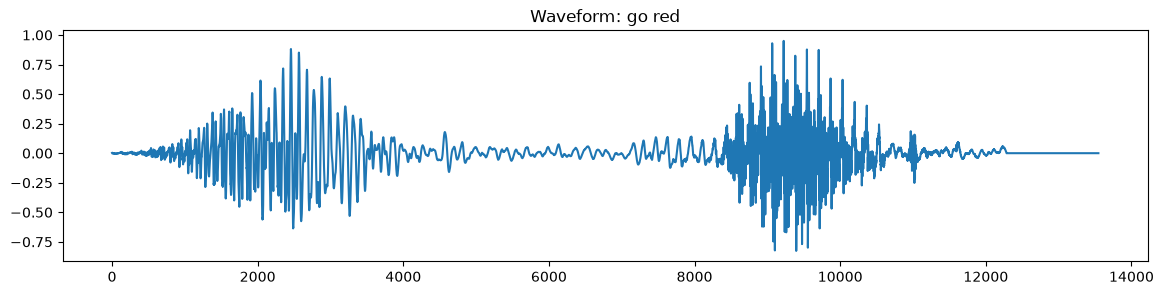

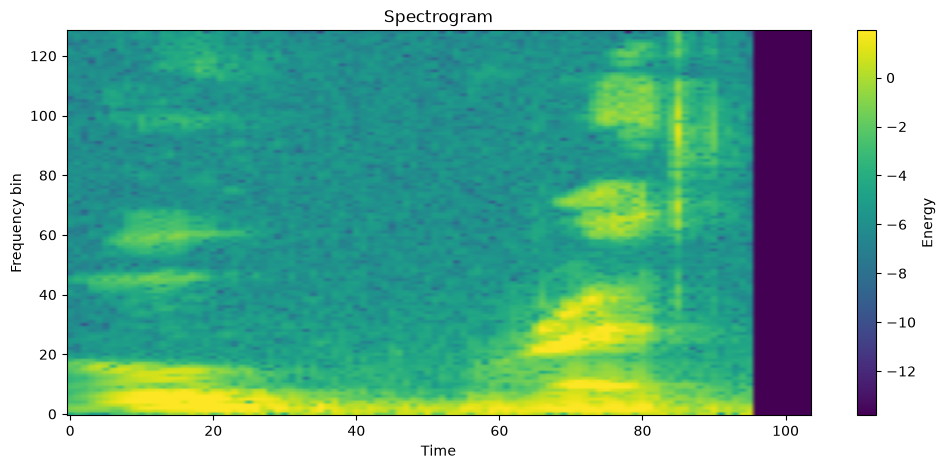

In [883]:
COMMAND_TO_PLOT = "go_red"   # change this to go_red, go_blue, go_green, go_yellow, hold, stop

plot_ds = load_audio_split("train", shuffle=False)
plot_ds = plot_ds.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)

target_label = list(label_names).index(COMMAND_TO_PLOT)

waveform = None
label = None

for audio_batch, label_batch in plot_ds:
    for i in range(len(label_batch)):
        if int(label_batch[i].numpy()) == target_label:
            waveform = audio_batch[i]
            label = int(label_batch[i].numpy())
            break
    if waveform is not None:
        break

trimmed_waveform = trim_for_plot(waveform)

spectrogram = get_spectrogram(
    tf.convert_to_tensor(trimmed_waveform, dtype=tf.float32)[tf.newaxis, :]
)

spectrogram = tf.squeeze(spectrogram, axis=0)
spec_2d = tf.squeeze(spectrogram, axis=-1).numpy()

plt.figure(figsize=(14, 3))
plt.plot(trimmed_waveform)
plt.title(f"Waveform: {COMMAND_PHRASES[label_names[label]]}")
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(
    spec_2d.T,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    vmin=np.percentile(spec_2d, 5),
    vmax=np.percentile(spec_2d, 99)
)
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency bin")
plt.colorbar(label="Energy")
plt.show()

## 12. Build and Train the Audio Classifier


In [884]:
train_spectrogram_ds = train_spectrogram_ds.shuffle(1000, seed=SEED).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

input_shape = example_spectrograms.shape[1:]
num_labels = len(label_names)
print("Input shape:", input_shape)
print("Number of labels:", num_labels)

norm_layer = layers.Normalization()
norm_layer.adapt(make_spec_ds(train_ds).map(lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(64, 64),
    norm_layer,
    layers.Conv2D(12, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(24, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(48, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.35),
    layers.Dense(num_labels),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

model.summary()


Input shape: (155, 129, 1)
Number of labels: 6


Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_60 (Resizing)          │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_60                │ (None, 64, 64, 1)      │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_180 (Conv2D)             │ (None, 64, 64, 12)     │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_180         │ (None, 64, 64, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_120               │ (None, 32, 32, 12)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_181 (Conv2D)             │ (None, 32, 32, 24)     │         2,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_181         │ (None, 32, 32, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_121               │ (None, 16, 16, 24)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_182 (Conv2D)             │ (None, 16, 16, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_182         │ (None, 16, 16, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_60     │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 6)              │           294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,785 (53.85 KB)

 Trainable params: 13,614 (53.18 KB)

 Non-trainable params: 171 (688.00 B)

In [1034]:
EPOCHS = 60
CHECKPOINT_PATH = MODEL_ROOT / "best_classifier.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        mode="max",
        restore_best_weights=True,
    ),
]

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 1.0000 - loss: 0.0198 - val_accuracy: 0.9420 - val_loss: 0.2126
Epoch 2/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 1.0000 - loss: 0.0219 - val_accuracy: 0.9130 - val_loss: 0.2459
Epoch 3/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 1.0000 - loss: 0.0300 - val_accuracy: 0.7681 - val_loss: 0.6693
Epoch 4/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 1.0000 - loss: 0.0295 - val_accuracy: 0.7826 - val_loss: 0.5290
Epoch 5/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9970 - loss: 0.0414 - val_accuracy: 0.6522 - val_loss: 1.7854
Epoch 6/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 1.0000 - loss: 0.0359 - val_accuracy: 0.5507 - val_loss: 1.9702
Epoch 7/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9939 - loss: 0.0340 - val_accuracy: 0.8406 - val_loss: 0.5730
Epoch 8/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9757 - loss: 0.0893 - val_accuracy: 0.6377 - v

In [1035]:
metrics = history.history
print("epoch, train_accuracy, val_accuracy, train_loss, val_loss")
for i in range(len(metrics["accuracy"])):
    print(
        f"{i + 1:02d}, "
        f"{metrics['accuracy'][i]:.4f}, "
        f"{metrics['val_accuracy'][i]:.4f}, "
        f"{metrics['loss'][i]:.4f}, "
        f"{metrics['val_loss'][i]:.4f}"
    )

best_epoch = int(np.argmax(metrics["val_accuracy"]))
print("\nBest validation epoch:", best_epoch + 1)
print("Best validation accuracy:", round(metrics["val_accuracy"][best_epoch], 4))


epoch, train_accuracy, val_accuracy, train_loss, val_loss
01, 1.0000, 0.9420, 0.0198, 0.2126
02, 1.0000, 0.9130, 0.0219, 0.2459
03, 1.0000, 0.7681, 0.0300, 0.6693
04, 1.0000, 0.7826, 0.0295, 0.5290
05, 0.9970, 0.6522, 0.0414, 1.7854
06, 1.0000, 0.5507, 0.0359, 1.9702
07, 0.9939, 0.8406, 0.0340, 0.5730
08, 0.9757, 0.6377, 0.0893, 1.1011
09, 0.9939, 0.8406, 0.0518, 0.3591
10, 0.9909, 0.8696, 0.0473, 0.3090
11, 1.0000, 0.8986, 0.0304, 0.2757

Best validation epoch: 1
Best validation accuracy: 0.942


## 13. Evaluate the Model


In [1036]:
model = tf.keras.models.load_model(CHECKPOINT_PATH)

test_metrics = model.evaluate(
    test_spectrogram_ds,
    return_dict=True
)

print(test_metrics)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9600 - loss: 0.2027 
{'accuracy': 0.9599999785423279, 'loss': 0.20268653333187103}


In [1037]:
metrics = history.history
print("epoch, train_accuracy, val_accuracy, train_loss, val_loss")
for i in range(len(metrics["accuracy"])):
    print(
        f"{i + 1:02d}, "
        f"{metrics['accuracy'][i]:.4f}, "
        f"{metrics['val_accuracy'][i]:.4f}, "
        f"{metrics['loss'][i]:.4f}, "
        f"{metrics['val_loss'][i]:.4f}"
    )

best_epoch = int(np.argmax(metrics["val_accuracy"]))
print("\nBest validation epoch:", best_epoch + 1)
print("Best validation accuracy:", round(metrics["val_accuracy"][best_epoch], 4))

epoch, train_accuracy, val_accuracy, train_loss, val_loss
01, 1.0000, 0.9420, 0.0198, 0.2126
02, 1.0000, 0.9130, 0.0219, 0.2459
03, 1.0000, 0.7681, 0.0300, 0.6693
04, 1.0000, 0.7826, 0.0295, 0.5290
05, 0.9970, 0.6522, 0.0414, 1.7854
06, 1.0000, 0.5507, 0.0359, 1.9702
07, 0.9939, 0.8406, 0.0340, 0.5730
08, 0.9757, 0.6377, 0.0893, 1.1011
09, 0.9939, 0.8406, 0.0518, 0.3591
10, 0.9909, 0.8696, 0.0473, 0.3090
11, 1.0000, 0.8986, 0.0304, 0.2757

Best validation epoch: 1
Best validation accuracy: 0.942


In [1038]:
y_true = []
y_pred = []

for spectrograms, labels in test_spectrogram_ds:
    logits = model.predict(spectrograms, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(logits, axis=1).tolist())

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(label_names)).numpy()

preferred_order = ["go_red", "go_blue", "go_green", "go_yellow", "hold", "stop"]

label_to_index = {label: i for i, label in enumerate(label_names)}
order_ids = [label_to_index[label] for label in preferred_order]

cm = cm[np.ix_(order_ids, order_ids)]
phrases = [COMMAND_PHRASES[label] for label in preferred_order]

print("Confusion matrix rows=actual, columns=predicted")
print("labels:", phrases)
print(cm)
correct = np.diag(cm)
totals = cm.sum(axis=1)
print("\nPer-command accuracy:")
for phrase, good, total in zip(phrases, correct, totals):
    acc = good / total if total else 0.0
    print(f"{phrase:10s}: {acc:.2%} ({good}/{total})")

Confusion matrix rows=actual, columns=predicted
labels: ['go red', 'go blue', 'go green', 'go yellow', 'hold', 'stop']
[[11  0  1  0  0  1]
 [ 0 12  0  0  0  0]
 [ 0  0 12  0  0  0]
 [ 0  0  0 12  0  0]
 [ 0  1  0  0 12  0]
 [ 0  0  0  0  0 13]]

Per-command accuracy:
go red    : 84.62% (11/13)
go blue   : 100.00% (12/12)
go green  : 100.00% (12/12)
go yellow : 100.00% (12/12)
hold      : 92.31% (12/13)
stop      : 100.00% (13/13)


## 14. Inference: Audio Command to Target State


In [619]:
def read_wav_for_inference(file_path):
    audio_binary = tf.io.read_file(str(file_path))
    audio, _ = tf.audio.decode_wav(
        audio_binary,
        desired_channels=1,
        desired_samples=OUTPUT_SEQUENCE_LENGTH,
    )
    return tf.squeeze(audio, axis=-1)


def command_to_target_state(command, confidence):
    confidence = float(confidence)
    phrase = COMMAND_PHRASES[command]

    if command == "stop" and confidence >= STOP_CONFIDENCE:
        state = dict(ACTION_MAP["stop"])
    elif confidence < MIN_CONFIDENCE:
        state = dict(ACTION_MAP["hold"])
        state["reason"] = "low_confidence_audio_prediction"
        state["raw_command"] = command
        state["raw_phrase"] = phrase
    else:
        state = dict(ACTION_MAP[command])

    state.update({
        "source": "audio_module",
        "command": command,
        "phrase": phrase,
        "confidence": confidence,
        "timestamp": time.time(),
    })
    return state

def predict_command_from_waveform(waveform):
    waveform, info = align_speech_to_fixed_length(
        waveform,
        target_samples=OUTPUT_SEQUENCE_LENGTH
    )

    if waveform is None:
        raise ValueError(f"Bad live audio: {info}")

    waveform = tf.convert_to_tensor(waveform, dtype=tf.float32)

    if len(waveform.shape) == 1:
        waveform = waveform[tf.newaxis, :]

    spec = get_spectrogram(waveform)
    logits = model(spec, training=False)
    probabilities = tf.nn.softmax(logits, axis=-1).numpy()[0]

    class_id = int(np.argmax(probabilities))
    command = str(label_names[class_id])
    confidence = float(probabilities[class_id])

    target_state = command_to_target_state(command, confidence)

    return command, confidence, probabilities, target_state


def predict_command_from_file(file_path):
    waveform = read_wav_for_inference(file_path)
    command, confidence, probabilities, target_state = predict_command_from_waveform(waveform)
    return {
        "file": str(file_path),
        "command": command,
        "phrase": COMMAND_PHRASES[command],
        "confidence": confidence,
        "probabilities": dict(zip(label_names.tolist(), probabilities.tolist())),
        "target_state": target_state,
    }


In [620]:
# Pick a test clip and run inference.
test_files = sorted((GOLD_SPLIT_DIR / "test").rglob("*.wav"))
if test_files:
    result = predict_command_from_file(test_files[0])
    print(json.dumps(result, indent=2))
else:
    print("No test files found yet.")


{
  "file": "C:\\Users\\aritr\\Downloads\\data\\gold\\audio\\commands\\test\\go_blue\\speaker02__go_blue__speaker02__go_blue__004.wav",
  "command": "go_blue",
  "phrase": "go blue",
  "confidence": 0.9373103380203247,
  "probabilities": {
    "go_blue": 0.9373103380203247,
    "go_green": 0.02046319842338562,
    "go_red": 0.0009091374231502414,
    "go_yellow": 0.03394621983170509,
    "hold": 0.006898932158946991,
    "stop": 0.00047224073205143213
  },
  "target_state": {
    "mode": "colour_select",
    "target_colour": "blue",
    "colour_setpoint": "blue",
    "hold": false,
    "emergency_stop": false,
    "source": "audio_module",
    "command": "go_blue",
    "phrase": "go blue",
    "confidence": 0.9373103380203247,
    "timestamp": 1783312771.1461554
  }
}


## 15. Live Microphone Inference and Main Loop Handoff


In [621]:
def record_live_waveform(clip_seconds=1.25):
    print(f"Recording {clip_seconds:.1f}s live command...")
    audio = sd.rec(
        int(clip_seconds * SAMPLE_RATE),
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype="float32",
    )
    sd.wait()
    return np.squeeze(audio, axis=-1)


def transmit_target_state(target_state, transmitter=None, out_path=LATEST_STATE_PATH):
    out_path = pathlib.Path(out_path)
    out_path.write_text(json.dumps(target_state, indent=2), encoding="utf-8")

    if transmitter is not None:
        transmitter(target_state)

    print("Transmitted target state:")
    print(json.dumps(target_state, indent=2))
    return target_state


def listen_once_and_emit_target_state(transmitter=None):
    waveform = record_live_waveform()
    command, confidence, probabilities, target_state = predict_command_from_waveform(waveform)
    return transmit_target_state(target_state, transmitter=transmitter)


def audio_module_step(main_execution_loop=None):
    transmitter = None
    if main_execution_loop is not None:
        transmitter = main_execution_loop.update_target_state
    return listen_once_and_emit_target_state(transmitter=transmitter)


# Uncomment after training:
#target_state = listen_once_and_emit_target_state()


In [622]:
#For testing, making a simple function where I can type the colour name instead of speaking and then expect the output.
def typed_colour_to_target_state(colour_name):
    colour_name = colour_name.strip().lower()

    colour_to_command = {
        "red": "go_red",
        "blue": "go_blue",
        "green": "go_green",
        "yellow": "go_yellow",
        "hold": "hold",
        "stop": "stop",
    }

    if colour_name not in colour_to_command:
        raise ValueError(
            f"Unknown colour/command: {colour_name}. "
            f"Use one of: {list(colour_to_command.keys())}"
        )

    command = colour_to_command[colour_name]

    # Manual typed command, so confidence is set to 1.0
    target_state = command_to_target_state(command, confidence=1.0)

    return transmit_target_state(target_state)

In [624]:
waveform = record_live_waveform(clip_seconds=1.25)

command, confidence, probabilities, target_state = predict_command_from_waveform(waveform)

print("Predicted:", command)
print("Confidence:", confidence)
print("All probabilities:")
print(dict(zip(label_names.tolist(), probabilities.tolist())))

print("\nTarget state:")
print(json.dumps(target_state, indent=2))

Recording 1.2s live command...


ValueError: Bad live audio: {'reason': 'too_quiet', 'peak': 0.000579833984375, 'rms': 0.00014165794709697366}

In [629]:
#Test the target state by running(manual test)

target_state = typed_colour_to_target_state("blue")

Transmitted target state:
{
  "mode": "colour_select",
  "target_colour": "blue",
  "colour_setpoint": "blue",
  "hold": false,
  "emergency_stop": false,
  "source": "audio_module",
  "command": "go_blue",
  "phrase": "go blue",
  "confidence": 1.0,
  "timestamp": 1783313332.6992502
}


In [665]:
#Test the target state by running(ML predicted model testing)
target_state = listen_once_and_emit_target_state()

Recording 1.2s live command...
Transmitted target state:
{
  "mode": "colour_select",
  "target_colour": "yellow",
  "colour_setpoint": "yellow",
  "hold": false,
  "emergency_stop": false,
  "source": "audio_module",
  "command": "go_yellow",
  "phrase": "go yellow",
  "confidence": 0.8540125489234924,
  "timestamp": 1783313888.2199285
}


## 16. Export Model and Metadata

In [131]:
label_names_tf = tf.constant(label_names)


class ExportModel(tf.Module):
    def __init__(self, trained_model):
        self.model = trained_model

        self.__call__.get_concrete_function(
            x=tf.TensorSpec(shape=(), dtype=tf.string)
        )
        self.__call__.get_concrete_function(
            x=tf.TensorSpec(shape=[None, OUTPUT_SEQUENCE_LENGTH], dtype=tf.float32)
        )

    @tf.function
    def __call__(self, x):
        if x.dtype == tf.string:
            x = tf.io.read_file(x)
            x, _ = tf.audio.decode_wav(
                x,
                desired_channels=1,
                desired_samples=OUTPUT_SEQUENCE_LENGTH,
            )
            x = tf.squeeze(x, axis=-1)
            x = x[tf.newaxis, :]

        spectrogram = get_spectrogram(x)
        logits = self.model(spectrogram, training=False)
        scores = tf.nn.softmax(logits, axis=-1)
        class_ids = tf.argmax(scores, axis=-1)
        class_names = tf.gather(label_names_tf, class_ids)
        confidence = tf.reduce_max(scores, axis=-1)

        return {
            "logits": logits,
            "scores": scores,
            "class_ids": class_ids,
            "class_names": class_names,
            "confidence": confidence,
        }


export = ExportModel(model)
SAVED_MODEL_DIR = MODEL_ROOT / "saved_model"
tf.saved_model.save(export, SAVED_MODEL_DIR)

(MODEL_ROOT / "labels.json").write_text(json.dumps(label_names.tolist(), indent=2), encoding="utf-8")
(MODEL_ROOT / "phrases.json").write_text(json.dumps(COMMAND_PHRASES, indent=2), encoding="utf-8")
(MODEL_ROOT / "action_map.json").write_text(json.dumps(ACTION_MAP, indent=2), encoding="utf-8")
(MODEL_ROOT / "audio_config.json").write_text(json.dumps({
    "sample_rate": SAMPLE_RATE,
    "clip_seconds": CLIP_SECONDS,
    "output_sequence_length": OUTPUT_SEQUENCE_LENGTH,
    "min_confidence": MIN_CONFIDENCE,
    "stop_confidence": STOP_CONFIDENCE,
}, indent=2), encoding="utf-8")

print("Saved model:", SAVED_MODEL_DIR)
print("Saved metadata:", MODEL_ROOT)


INFO:tensorflow:Assets written to: C:\Users\aritr\Downloads\models\audio_command_classifier\saved_model\assets


INFO:tensorflow:Assets written to: C:\Users\aritr\Downloads\models\audio_command_classifier\saved_model\assets


Saved model: C:\Users\aritr\Downloads\models\audio_command_classifier\saved_model
Saved metadata: C:\Users\aritr\Downloads\models\audio_command_classifier


In [132]:
# Optional TensorFlow Lite export for edge deployment.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = MODEL_ROOT / "audio_command_classifier.tflite"
tflite_path.write_bytes(tflite_model)
print("Saved TFLite model:", tflite_path)


INFO:tensorflow:Assets written to: C:\Users\aritr\AppData\Local\Temp\tmp85pv1m79\assets


INFO:tensorflow:Assets written to: C:\Users\aritr\AppData\Local\Temp\tmp85pv1m79\assets


Saved artifact at 'C:\Users\aritr\AppData\Local\Temp\tmp85pv1m79'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 61, 257, 1), dtype=tf.float32, name='keras_tensor_70')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  1852858362448: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  1852858366288: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  1852782607248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858364944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858359184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858361488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858363984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858363216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858362256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1852858360912: TensorSpec(shape=(), dtype=tf.resource